In [1]:
from typing import Tuple

import torch
from torch import nn, Tensor
from torch.distributions.beta import Beta
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
import torch.backends.cudnn as cudnn

import matplotlib.pyplot as plt
import numpy as np

from tqdm.notebook import tqdm_notebook

In [2]:
class MixUpModule(nn.Module):
    """
    Module MixUp that mixes batch and labels with a parameter lambda sampled from a beta distribution.
    Code overview :
    >>> lambda ~ Beta(alpha, alpha)
    >>> lambda = max(lambda, 1 - lambda)
    >>> batch = batch_a * lambda + batch_b * (1 - lambda)
    >>> label = label_a * lambda + label_b * (1 - lambda)
    Notes:
            - if alpha -> 0 and apply_max == True, lambda sampled near 1,
            - if alpha -> 1 and apply_max == True, lambda sampled from an uniform distribution in [0.5, 1.0],
            - if alpha -> 0 and apply_max == False, lambda sampled near 1 or 0,
            - if alpha -> 1 and apply_max == False, lambda sampled from an uniform distribution in [0.0, 1.0],
    """

    def __init__(self, sample_lambda: bool = True, _lambda: float = 0.5, alpha: float = 0.4, apply_max: bool = False) -> None:
        """
        Build the MixUp Module.
        :param alpha: Controls the Beta distribution used to sample the lambda coefficient. (default: 0.4)
        :param apply_max: If True, apply the 'lambda = max(lambda, 1 - lambda)' after the sampling of lambda. (default: False)
                This operation is useful for having a mixed batch close to the first batch passed as input.
                It was set to True in MixMatch training but not in original MixUp training.
        """
        super().__init__()
        self.alpha = alpha
        self.apply_max = apply_max

        self.sample_lambda = sample_lambda
        if self.sample_lambda:
            self._beta = Beta(alpha, alpha)
        self._lambda = _lambda

    def forward(
        self,
        xa: Tensor,
        xb: Tensor,
        ya: Tensor,
        yb: Tensor,
    ) -> Tuple[Tensor, Tensor]:
        """
        Apply MixUp to batches and labels.
        """
        if xa.shape != xb.shape or ya.shape != yb.shape:
            raise RuntimeError(
                "Invalid shapes for MixUp : ({} != {} or {} != {})".format(
                    xa.shape, xb.shape, ya.shape, yb.shape
                )
            )

        # Sample from Beta distribution
        if self.sample_lambda:
            self._lambda = self._beta.sample().item() if self.alpha > 0.0 else 1.0

        if self.apply_max:
            self._lambda = max(self._lambda, 1.0 - self._lambda)

        batch_mix = xa * self._lambda + xb * (1.0 - self._lambda)
        labels_mix = ya * self._lambda + yb * (1.0 - self._lambda)

        return batch_mix, labels_mix

    def get_last_lambda(self) -> float:
        """
        :returns: the last lambda sampled. If no data has been passed to forward(), returns 0.0.
        """
        return self._lambda

# Chargement de CIFAR10

In [3]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

target_transform = transforms.Compose(
    [lambda x:torch.LongTensor([x]),
      lambda x:nn.functional.one_hot(x,10),
     lambda x:torch.squeeze(x)])

batch_size = 4

path= "/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TPIA3_1/"

trainset = torchvision.datasets.CIFAR10(root=path+'data', train=True,
                                        download=True, transform=transform,
                                        target_transform=target_transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)

testset = torchvision.datasets.CIFAR10(root=path+'data', train=False,
                                       download=True, transform=transform,
                                       target_transform=target_transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=0)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [4]:
def onehot2int(onehot):
    _, ilabels = torch.max(onehot, dim=-1)
    return ilabels


def imshow(images, labels=None, predicted_labels=None):
    # Using torchvision to make a grid of the images
    img = torchvision.utils.make_grid(images)

    img = img / 2 + 0.5     # unnormalize
    img = img.permute(1, 2, 0)

    # Plotting the grid
    fig, ax = plt.subplots(figsize=(12, 48))
    plt.imshow(img)

    if predicted_labels is not None:
        # labels prédits si elles existent
        ax.set_xlabel('Predicted labels', fontsize=18, labelpad=12)
        ax.set_xticks(torch.arange(len(images)) * 35 + 20)
        ax.set_xticklabels([classes[predicted_labels[j]]
                            for j in range(len(images))], fontsize=14)

    # labels ground truth
    gax = ax.secondary_xaxis('top')
    # gax.set_xlabel('Ground truth', fontsize=18, labelpad=12)
    gax.set_xticks(torch.arange(len(images)) * 35 + 20)
    if labels is not None:
        int_classes = onehot2int(labels)
        gax.set_xticklabels([classes[int_classes[j].item()] #type: ignore
                         for j in range(len(images))], fontsize=14)
    plt.show()

# Test mixup

In [5]:
# Images random du train
dataiter = iter(trainloader)
images1, labels1 = next(dataiter)
images2, labels2 = next(dataiter)

In [6]:
labels1.size()

torch.Size([4, 10])

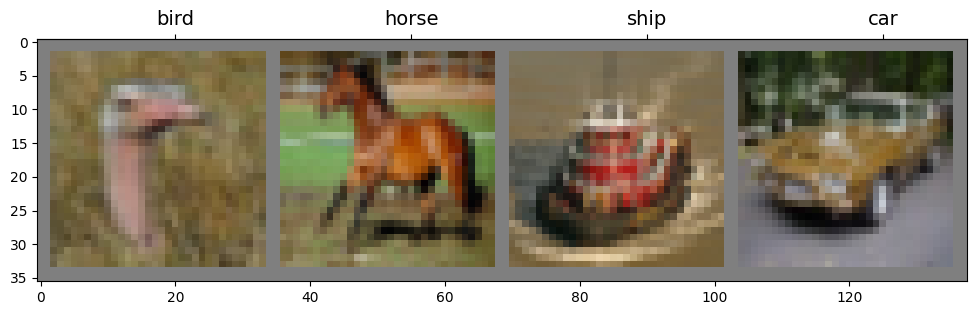

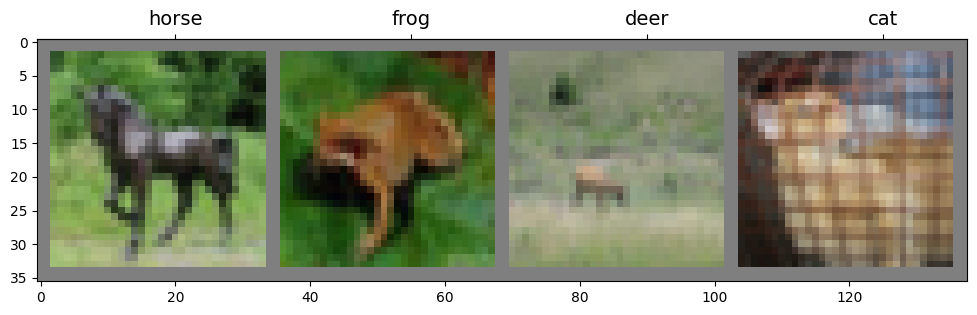

In [7]:
imshow(images1, labels1)
imshow(images2, labels2)

# Essayer Mixup avec les arguments par défaut

In [8]:
mixup = MixUpModule(alpha = 0.09)

In [9]:
mixed_x, mixed_y = mixup(images1, images2, labels1, labels2)
print(f"lambda = {mixup.get_last_lambda():.3f}")
print("labels1", labels1.size())
print("mixed_y", mixed_y.size())
print(mixed_y)
labels1_int = onehot2int(labels1)
print("labels1_int", labels1_int.size())


lambda = 0.283
labels1 torch.Size([4, 10])
mixed_y torch.Size([4, 10])
tensor([[0.0000, 0.0000, 0.2828, 0.0000, 0.0000, 0.0000, 0.0000, 0.7172, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.7172, 0.2828, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.7172, 0.0000, 0.0000, 0.0000, 0.2828,
         0.0000],
        [0.0000, 0.2828, 0.0000, 0.7172, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000]])
labels1_int torch.Size([4])


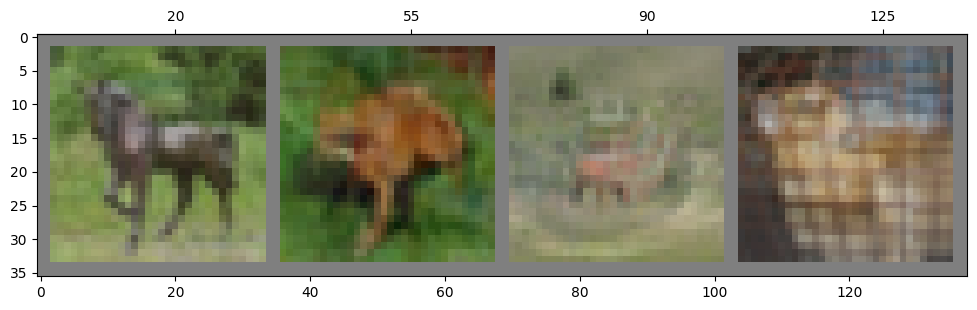

In [10]:
imshow(mixed_x)

# Essayer Mixup avec différentes valeurs de alpha

In [11]:
mixup = MixUpModule( alpha = 0.99) 

In [12]:
mixed_x, mixed_y = mixup(images1, images2, labels1, labels2)
print(f"lambda = {mixup.get_last_lambda():.3f}")
print("labels1", labels1.size())
print("mixed_y", mixed_y.size())
print(mixed_y)
labels1_int = onehot2int(labels1)
print("labels1_int", labels1_int.size())

lambda = 0.017
labels1 torch.Size([4, 10])
mixed_y torch.Size([4, 10])
tensor([[0.0000, 0.0000, 0.0168, 0.0000, 0.0000, 0.0000, 0.0000, 0.9832, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.9832, 0.0168, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.9832, 0.0000, 0.0000, 0.0000, 0.0168,
         0.0000],
        [0.0000, 0.0168, 0.0000, 0.9832, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000]])
labels1_int torch.Size([4])


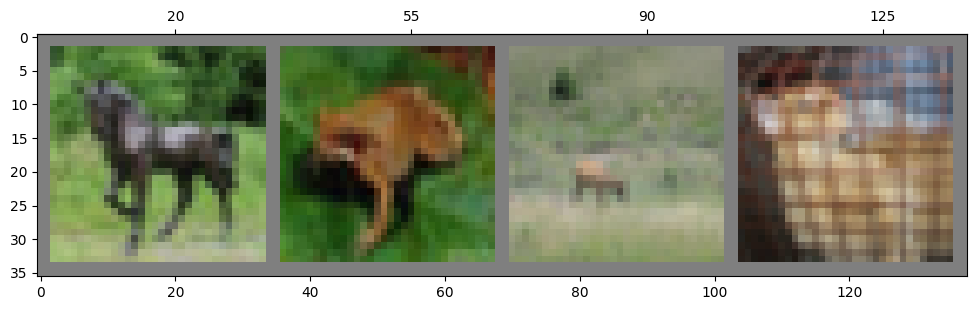

In [13]:
imshow(mixed_x)

# Essayer Mixup avec des valeurs que vous fixez pour lambda, sans sampling

lambda = 0.963
labels1 torch.Size([4, 10])
mixed_y torch.Size([4, 10])
tensor([[0.0000, 0.0000, 0.9630, 0.0000, 0.0000, 0.0000, 0.0000, 0.0370, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0370, 0.9630, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0370, 0.0000, 0.0000, 0.0000, 0.9630,
         0.0000],
        [0.0000, 0.9630, 0.0000, 0.0370, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000]])
labels1_int torch.Size([4])


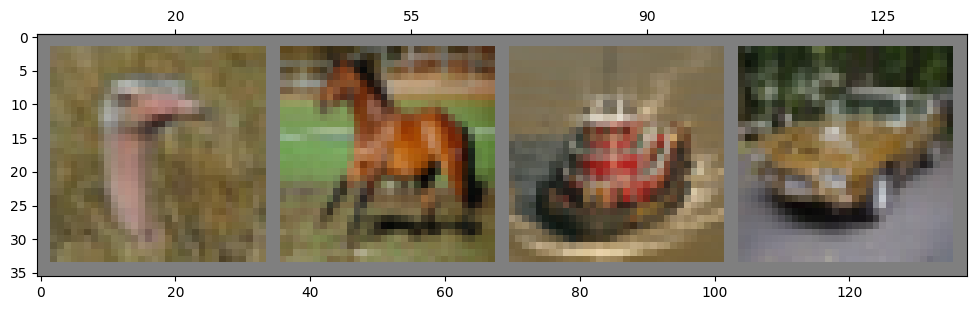

In [14]:
mixup = MixUpModule(_lambda=0.5)
mixed_x, mixed_y = mixup(images1, images2, labels1, labels2)
print(f"lambda = {mixup.get_last_lambda():.3f}")
print("labels1", labels1.size())
print("mixed_y", mixed_y.size())
print(mixed_y)
labels1_int = onehot2int(labels1)
print("labels1_int", labels1_int.size())
imshow(mixed_x)

# CNN avec et sans Mixup

Entraîner et tester sur CIFAR10 un réseau CNN from scratch sans et avec Mixup.



In [15]:
# On change le batch size à 32 et non 4 dans la cellule en haut du notebook pour les dataloaders, sinon ce sera très très lent (et moins performant)

batch_size = 32

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)

testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=0)

In [16]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:

print(device)

mps


In [17]:
def train(testloader, trainloader, model, opt, crit, use_mixup=False, n_epoch=2, loss_every=500):
    """
    Entraînement d'un modèle et plot des courbes de loss et accuracy
    """
    model.train()
    losses = []
    acc = []

    if use_mixup:
      mixup = MixUpModule(apply_max=True)

    test_acc = accuracy(testloader, model)
    print(f"Test accuracy: {test_acc:.3f}")

    for epoch in range(n_epoch):  # loop over the dataset multiple times
        print(f"Epoch {epoch}.")

        running_loss = []
        running_acc = []
        print("Train.")
        for i, data in tqdm_notebook(enumerate(trainloader), total=len(trainloader)):

            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            # Mettre à zero les gradients des poids du modèle
            opt.zero_grad()

            # forward + backward + optimize
            if use_mixup:
              perm = torch.randperm(inputs.size(0))
              inputs2 = inputs[perm]
              labels2 = labels[perm]
              mixed_inputs, mixed_labels = mixup(inputs, inputs2, labels, labels2)
              outputs = model(mixed_inputs)
              loss = crit(outputs, mixed_labels)
              # labels = onehot2int(labels)
              # loss = crit(outputs, labels)
            else:
              outputs = model(inputs)
              labels = onehot2int(labels)
              loss = crit(outputs, labels)
            loss.backward()
            opt.step()

            # predicted = torch.argmax(outputs, dim=1)

            running_loss.append(loss.item())
            # running_acc.append((predicted == labels).sum().item() / labels.size(0))

            # calculer une moyenne
            if i % loss_every:
                losses.append(np.mean(running_loss))
                acc.append(np.mean(running_acc))

                running_loss = []
                # running_acc = []

        test_acc = accuracy(testloader, model)
        print(f"Test accuracy: {test_acc:.3f}")

    fig, axes = plt.subplots(1, 2)
    axes[0].plot(losses)
    # axes[1].plot(acc)

    axes[0].set_ylabel("Train loss")
    # axes[1].set_ylabel("Train acc")
    plt.show()
    print('Apprentissage terminé')


def accuracy(loader, model):
    """
    Args:
        loader: data loader sur lequel on veut calculer une accuracy
        model
    Returns:
        Accuracy
    """
    with torch.no_grad():
        model.eval()  # remove potential dropout, ...
        n_correct = 0
        n_total = 0
        for i, data in tqdm_notebook(enumerate(loader), total=len(loader)):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            # forward + backward + optimize
            outputs = model(inputs)
            predicted = torch.argmax(outputs, dim=1)
            labels = onehot2int(labels)
            # print("predicted", predicted)
            # print("labels", labels.size())
            n_correct += (predicted == labels).sum()
            n_total += labels.size(0)
        return n_correct / n_total


def validate(loader, model):
    """
    Plot des predictions faites avec model, affiche l'accuracy
    """
    dataiter = iter(loader)
    # Get one batch of data
    images, labels = next(dataiter)
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    predictions = torch.argmax(outputs, dim=1)

    accuracy_model = accuracy(loader, model)

    # print images
    print(f'Accuracy: {accuracy_model.detach().cpu().item():.3f}')
    imshow(images[:4].detach().cpu(), labels[:4], predicted_labels=predictions[:4])


## Sans mixup

In [18]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [19]:
net = Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

  0%|          | 0/313 [00:00<?, ?it/s]

Test accuracy: 0.100
Epoch 0.
Train.


  0%|          | 0/1563 [00:00<?, ?it/s]

/Users/asriel/miniconda3/envs/LLMs/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/asriel/miniconda3/envs/LLMs/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  0%|          | 0/313 [00:00<?, ?it/s]

...

  0%|          | 0/313 [00:00<?, ?it/s]

Test accuracy: 0.629
Epoch 19.
Train.


  0%|          | 0/1563 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

Test accuracy: 0.629


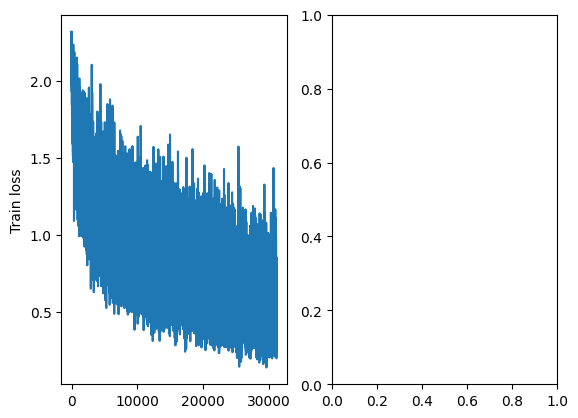

Apprentissage terminé


In [20]:
train(testloader, trainloader, net, optimizer, criterion, n_epoch=20)

  0%|          | 0/313 [00:00<?, ?it/s]

Accuracy: 0.629


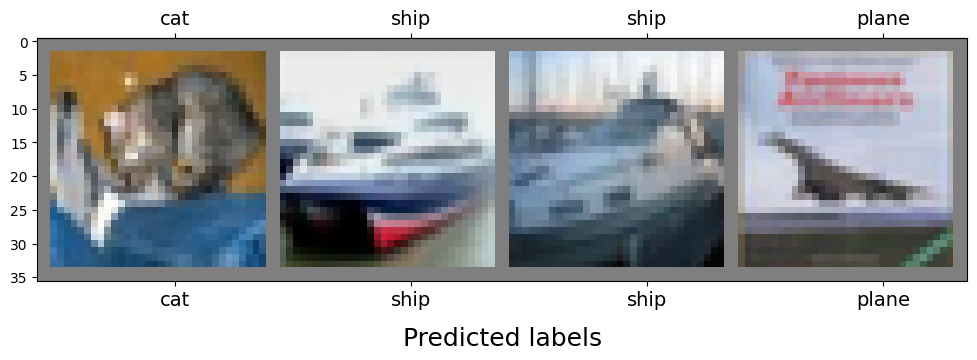

In [21]:
validate(testloader, net)

# Avec Mixup

In [22]:
net = Net().to(device)
# criterion = nn.CrossEntropyLoss()
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

  0%|          | 0/313 [00:00<?, ?it/s]

Test accuracy: 0.100
Epoch 0.
Train.


  0%|          | 0/1563 [00:00<?, ?it/s]

/Users/asriel/miniconda3/envs/LLMs/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/asriel/miniconda3/envs/LLMs/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  0%|          | 0/313 [00:00<?, ?it/s]

...

  0%|          | 0/313 [00:00<?, ?it/s]

Test accuracy: 0.657
Epoch 29.
Train.


  0%|          | 0/1563 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

Test accuracy: 0.653


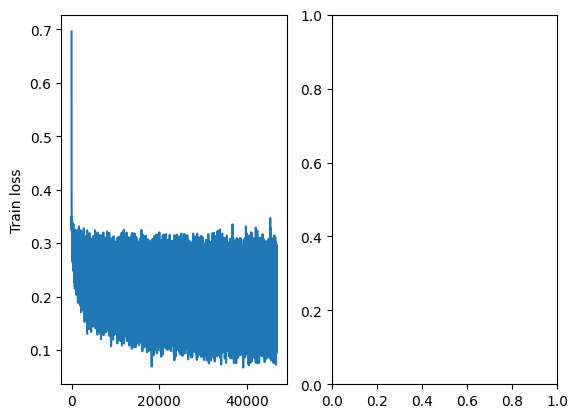

Apprentissage terminé


In [23]:
train(testloader, trainloader, net, optimizer, criterion, use_mixup=True, n_epoch=30)

  0%|          | 0/313 [00:00<?, ?it/s]

Accuracy: 0.653


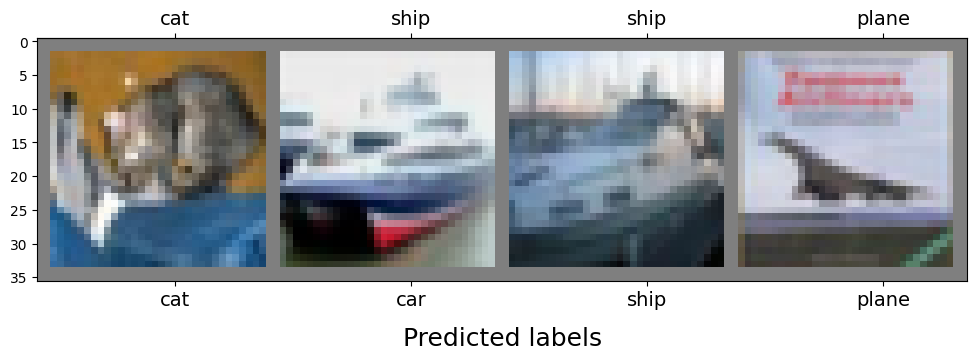

In [24]:
validate(testloader, net)

# ResNet18

Entraîner et tester sur CIFAR10 un réseau ResNet18 from scratch sans et avec Mixup

In [25]:
import os
import torch
import torchvision
import tarfile
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
from torchvision.datasets.utils import download_url
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.transforms as tt
from torch.utils.data import random_split
from torchvision.utils import make_grid
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

matplotlib.rcParams['figure.facecolor'] = '#ffffff'
#project_name='05b-cifar10-resnet'
filename='05b-cifar10-resnet'

In [26]:
from torchvision.datasets.utils import download_url

rep_path= "/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TPIA3_1/"

# Dowload the dataset
dataset_url = "https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz"
download_url(dataset_url, '.')

# Extract from archive
with tarfile.open('./cifar10.tgz', 'r:gz') as tar:
    tar.extractall(path=rep_path+'data')
    
# Look into the data directory
data_dir = rep_path + 'data/cifar10'
print(os.listdir(data_dir))
classes = os.listdir(data_dir + "/train")
print(classes)

['test', 'train']
['cat', 'dog', 'truck', 'bird', 'airplane', 'ship', 'frog', 'horse', 'deer', 'automobile']


In [27]:
# Data transforms (normalization & data augmentation)
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
train_tfms = tt.Compose([tt.RandomCrop(32, padding=4, padding_mode='reflect'), 
                         tt.RandomHorizontalFlip(), 
                         # tt.RandomRotate
                         # tt.RandomResizedCrop(256, scale=(0.5,0.9), ratio=(1, 1)), 
                         # tt.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
                         tt.ToTensor(), 
                         tt.Normalize(*stats,inplace=True)])
valid_tfms = tt.Compose([tt.ToTensor(), tt.Normalize(*stats)])

In [28]:
# PyTorch datasets
train_ds = ImageFolder(data_dir+'/train', train_tfms)
valid_ds = ImageFolder(data_dir+'/test', valid_tfms)

In [29]:
batch_size = 400
# PyTorch data loaders
train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=0, pin_memory=False)
valid_dl = DataLoader(valid_ds, batch_size*2, num_workers=0, pin_memory=False)

In [30]:
def denormalize(images, means, stds):
    means = torch.tensor(means).reshape(1, 3, 1, 1)
    stds = torch.tensor(stds).reshape(1, 3, 1, 1)
    return images * stds + means

def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(12, 12))
        ax.set_xticks([]); ax.set_yticks([])
        denorm_images = denormalize(images, *stats)
        ax.imshow(make_grid(denorm_images[:64], nrow=8).permute(1, 2, 0).clamp(0,1))
        break

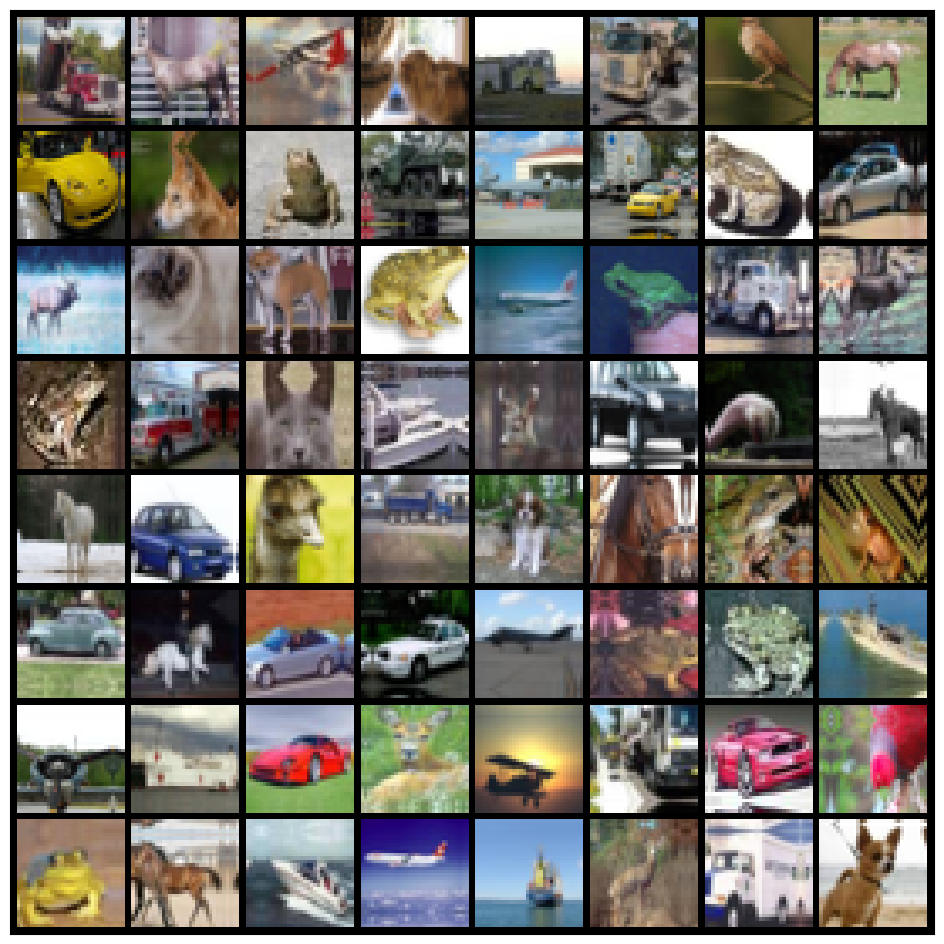

In [31]:
show_batch(train_dl)

In [32]:
def get_default_device():
    if torch.backends.mps.is_available(): 
        return torch.device("mps") 
    else:
        return torch.device('cpu')
    
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
        
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl: 
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)    
    
device =  get_default_device()  

#train_dl = DeviceDataLoader(train_dl, device)
#valid_dl = DeviceDataLoader(valid_dl, device)

In [33]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch 
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss
 
    def validation_step(self, batch):
        images, labels = batch 
        images = images.to(next(self.parameters()).device)
        labels = labels.to(next(self.parameters()).device)

        out = self(images)                    # logits
        loss = F.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return {'val_loss': loss.detach(), 'val_acc': acc}
        
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}
    
    def epoch_end(self, epoch, result):
        print("Epoch [{}], last_lr: {:.5f}, train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['lrs'][-1], result['train_loss'], result['val_loss'], result['val_acc']))

In [34]:
from torchvision.models import resnet18

class ResNet18Mixup(ImageClassificationBase):
    def __init__(self, num_classes,mixup:bool = True):
        super().__init__()
        self.mixup = mixup
        self.model = resnet18(weights=None)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
    
    def forward(self, x):
        return self.model(x)

In [35]:
def mixup_batch(x, y, num_classes=10, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    indices = torch.randperm(x.size(0), device=x.device)

    x1, x2 = x, x[indices]
    y1 = F.one_hot(y, num_classes=num_classes).float()
    y2 = F.one_hot(y[indices], num_classes=num_classes).float()

    x_mixed = lam * x1 + (1 - lam) * x2
    y_mixed = lam * y1 + (1 - lam) * y2
    return x_mixed, y_mixed

In [36]:
def cross_entropy_soft(targets, logits):
    # targets: (B, C) soft / one-hot, logits: (B, C)
    log_probs = F.log_softmax(logits, dim=1)
    return -(targets * log_probs).sum(dim=1).mean()

In [37]:
def train_modele (model, optimizer, num_classes , num_epochs):
    history = []
    for epoch in range(num_epochs):
        # --- TRAIN ---
        model.train()
        running_loss = 0.0
        n_samples = 0

        for images, labels in train_dl:
            images = images.to(device)
            labels = labels.to(device)

            # Mixup
            if model.mixup: 
                images_m, targets_m = mixup_batch(images, labels, num_classes=num_classes, alpha=0.4)
            else: 
                images_m = images 
                targets_m = labels

            logits = model(images_m)
            loss = cross_entropy_soft(targets_m, logits)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            bs = images.size(0)
            running_loss += loss.item() * bs
            n_samples += bs

        train_loss = running_loss / n_samples

        # --- VALIDATION ---
        model.eval()
        with torch.no_grad():
            val_outputs = []
            for batch in valid_dl:
                val_outputs.append(model.validation_step(batch))
            result = model.validation_epoch_end(val_outputs)
            result['train_loss'] = train_loss
            # si tu as un scheduler avec OneCycleLR par ex.:
            result['lrs'] = [optimizer.param_groups[0]['lr']] #type: ignore

        model.epoch_end(epoch, result)
        history.append(result)

## Sans mixup

In [38]:
num_classes = 10  # adapté au dataset
model_sans = ResNet18Mixup(num_classes,False).to(device)
optimizer = torch.optim.AdamW(model_sans.parameters(), lr=1e-3, weight_decay=1e-2)
num_epochs = 4
train_modele (model_sans, optimizer, num_classes , num_epochs)

RuntimeError: The size of tensor a (400) must match the size of tensor b (10) at non-singleton dimension 1

## Avec mixup

In [ ]:
num_classes = 10  # adapté au dataset
model_avec = ResNet18Mixup(num_classes,True).to(device)
optimizer = torch.optim.AdamW(model_avec.parameters(), lr=1e-3, weight_decay=1e-2)
num_epochs = 4
train_modele (model_avec, optimizer, num_classes , num_epochs)